In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity("WARNING")
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    save_path="./scarf_datasets",
    as_zarr=True,
)

In [3]:
ds = scarf.DataStore(
    "scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

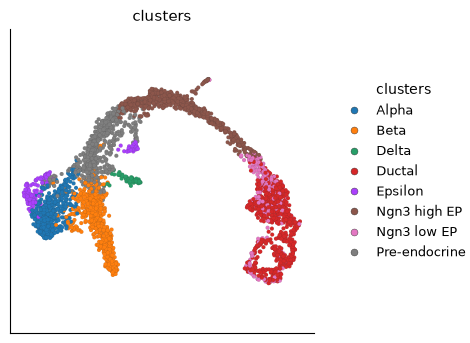

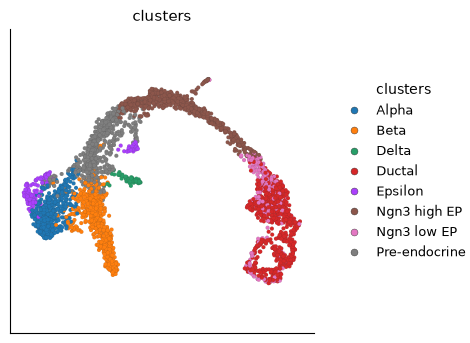

In [4]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
).figure

In [5]:
ds.run_cell_cycle_scoring()

1 values were not found in the table column names



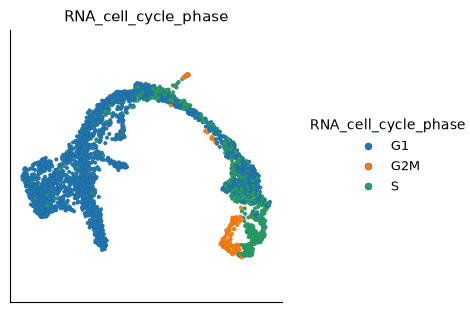

In [6]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cell_cycle_phase",
).figure

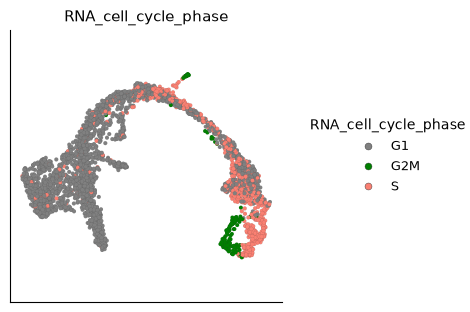

In [7]:
color_key = {
    "G1": "grey",
    "S": "salmon",
    "G2M": "green",
}

splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cell_cycle_phase",
    categorical_scale=splt.CategoricalScale(palette=color_key),
).figure

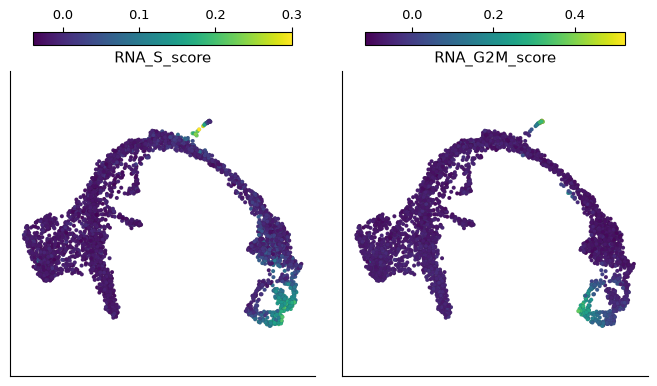

In [8]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by=["RNA_S_score", "RNA_G2M_score"],
).figure

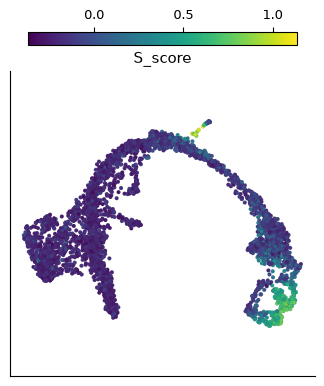

In [9]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="S_score",
).figure

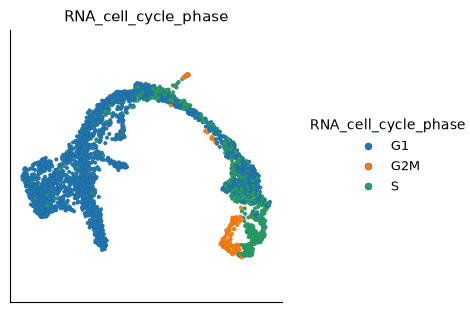

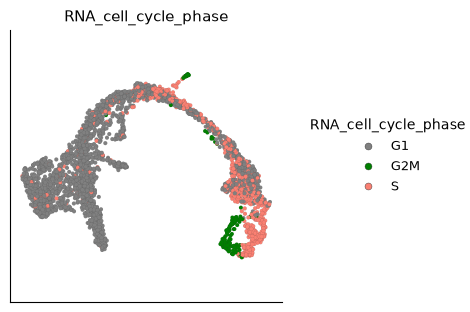

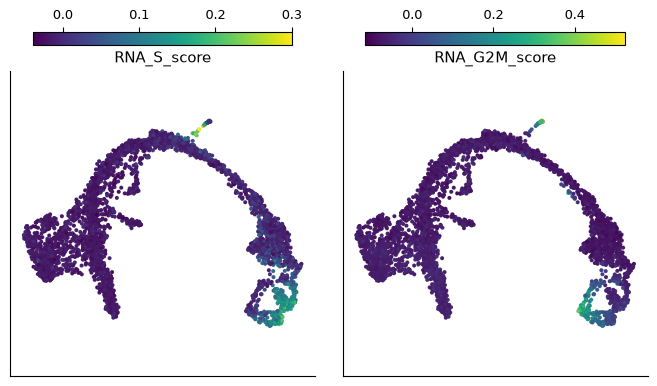

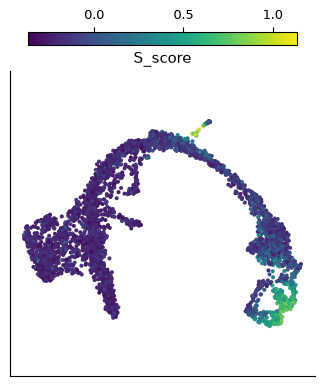

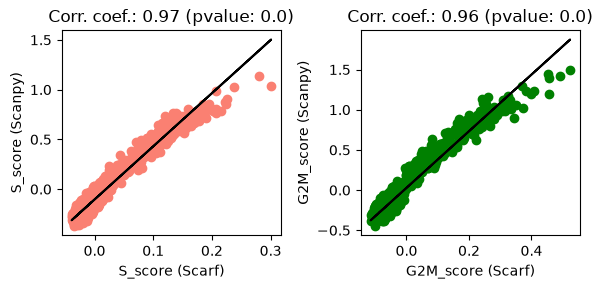

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, axis = plt.subplots(1, 2, figsize=(6, 3))
for n, i in enumerate(["S_score", "G2M_score"]):
    x = ds.cells.fetch(f"RNA_{i}")
    y = ds.cells.fetch(i)
    res = linregress(x, y)

    ax = axis[n]
    ax.scatter(x, y, color=color_key[i.split("_")[0]])
    ax.plot(x, res.intercept + res.slope * x, label="fitted line", c="k")
    ax.set_xlabel(f"{i} (Scarf)")
    ax.set_ylabel(f"{i} (Scanpy)")
    ax.set_title(f"Corr. coef.: {round(res.rvalue, 2)} (pvalue: {res.pvalue})")

plt.tight_layout()
plt.show()